<a href="https://colab.research.google.com/github/dinusariehewage-coder/ET3112---Assignment-02/blob/main/Q06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Screenshot 2026-03-20 003555.png to Screenshot 2026-03-20 003555 (4).png
TLS Slope: -3.879313395771615
TLS Intercept: 351.2839999147169


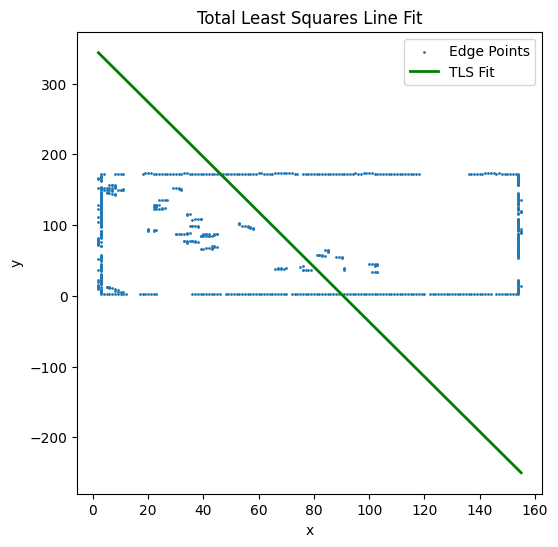

In [8]:

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


uploaded = files.upload()

# Read image (grayscale)
img = cv.imread('/content/Screenshot 2026-03-20 003555 (1).png', 0)

# Apply Canny edge detection
edges = cv.Canny(img, 550, 690)

# Extract (x, y) coordinates
indices = np.where(edges != 0)
x = indices[1]
y = indices[0]


points = np.vstack((x, y)).T


mean = np.mean(points, axis=0)

points_centered = points - mean

U, S, Vt = np.linalg.svd(points_centered)


direction = Vt[0]


m_tls = direction[1] / direction[0]
c_tls = mean[1] - m_tls * mean[0]

print("TLS Slope:", m_tls)
print("TLS Intercept:", c_tls)


x_line = np.linspace(min(x), max(x), 100)
y_line = m_tls * x_line + c_tls

# Plot scatter + TLS line
plt.figure(figsize=(6,6))
plt.scatter(x, y, s=1, label="Edge Points")
plt.plot(x_line, y_line, color='green', linewidth=2, label="TLS Fit")

plt.title("Total Least Squares Line Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()